# Практическое задание «Оценка точности модели, переобучение, регуляризация»

В этом ноутбуке вы:
1. обучите базовую логистическую регрессию;
2. оцените её качество с помощью `Accuracy`, `Precision`, `Recall`, `F1`, `ROC-AUC`, `PR-AUC`;
3. проанализируете матрицу ошибок;
4. сравните несколько способов кросс-валидации;
5. сравните L1- и L2-регуляризацию.

Во всех частях используется один и тот же датасет **Fair / Affairs** из `statsmodels`.

## Что уже подготовлено в шаблоне

Чтобы вы могли сосредоточиться на логике задания, в файле уже есть:
- все импорты;
- загрузка датасета;
- каркас графиков;
- вспомогательные функции;
- места, где нужно дописать код;
- вопросы для коротких выводов.

Ваша задача — заполнить отмеченные места и кратко интерпретировать результаты.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

In [2]:
def build_model(penalty="l2", C=1.0):
    # Пайплайн: масштабирование с логистической регрессией
    return Pipeline([
        ("scaler", StandardScaler()), 
        ("model", LogisticRegression(
            max_iter=2000,  # больше итераций, чтобы солвер успел сойтись
            solver="liblinear",  # поддерживает и L1, и L2
            penalty=penalty,  # тип регуляризации: l1 или l2
            C=C  # сила регуляризации: меньше C → сильнее штраф
        ))
    ])

def plot_confusion_heatmap(cm, labels=("Нет измены", "Была измена")):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
    ax.set_title("Матрица ошибок")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.show()


## 1. Загрузка данных и минимальная подготовка

Используйте датасет **Fair / Affairs** из `statsmodels`.
Целевая переменная должна быть бинарной:

- `1`, если `affairs > 0`
- `0`, если `affairs == 0`

Обратите внимание: в исходном датасете признаки уже числовые, поэтому отдельное кодирование категориальных признаков здесь не требуется.

In [3]:
# Загружаем готовый датасет Fair/Affairs из statsmodels
df = sm.datasets.fair.load_pandas().data.copy()
df.head()


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [4]:
# Создаём бинарную цель: 1 = была измена, 0 = не было
df["affair_flag"] = (df["affairs"] > 0).astype(int)

# Считаем, сколько пропусков во всей таблице
missing_values = int(df.isna().sum().sum())

# Доля класса 1 среди всех строк
positive_share = df["affair_flag"].mean()

print("Размер датасета:", df.shape)
print("Суммарное число пропусков:", missing_values)
print("Доля положительного класса:", positive_share)
display(df.head())


Размер датасета: (6366, 10)
Суммарное число пропусков: 0
Доля положительного класса: 0.3224945020420987


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,affair_flag
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1


### Короткий вывод

1. Пропусков **нет** (0).
2. Классы **не сбалансированы**: положительный класс ≈ **32%**, отрицательный ≈ **68%**.
3. Признаки уже числовые, пропусков нет — для этого урока хватает создать бинарную цель и сделать train/test split.


In [5]:
# Признаки: всё, кроме исходного affairs и нашей цели
X = df.drop(columns=["affairs", "affair_flag"])

# Целевая переменная
y = df["affair_flag"]

# Делим 70/30, stratify сохраняет долю классов в train и test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (4456, 8)
X_test: (1910, 8)


## 2. Базовая логистическая регрессия и основные метрики

Обучите базовую модель логистической регрессии и оцените её качество.
Посчитайте:

- `accuracy`
- `precision`
- `recall`
- `f1-score`

Также выведите метрики для **обоих классов**.

In [6]:
# Базовая модель: StandardScaler + LogisticRegression (L2, C=1 по умолчанию)
baseline_model = build_model()

# Учимся только на train
baseline_model.fit(X_train, y_train)

# Классы 0/1 на тесте
y_pred = baseline_model.predict(X_test)

# Вероятность класса 1 — нужна для ROC/PR
y_proba = baseline_model.predict_proba(X_test)[:, 1]


In [7]:
# Основные метрики для положительного класса (по умолчанию pos_label=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "value": [accuracy, precision, recall, f1]
})

display(metrics_table)

# Подробный отчёт по обоим классам
report = classification_report(y_test, y_pred, digits=3, output_dict=True)
report = pd.DataFrame(report).T
display(report)


,metric,value
0,accuracy,0.714660
1,precision,0.591731
2,recall,0.371753
3,f1,0.456630


,precision,recall,f1-score,support
0,0.745896,0.877898,0.806532,1294.00000
1,0.591731,0.371753,0.456630,616.00000
accuracy,0.714660,0.714660,0.714660,0.71466
macro avg,0.668814,0.624826,0.631581,1910.00000
weighted avg,0.696176,0.714660,0.693684,1910.00000


### Короткий вывод

1. Выше всего **accuracy ≈ 0.715** — модель часто правильно угадывает «не было измены».
2. Сильнее всего проседает **recall ≈ 0.372** (и F1 ≈ 0.457): многие реальные измены модель пропускает.
3. Модель слабо работает с положительным классом: лучше не обвинит, чем найдёт все случаи.


## 3. Матрица ошибок

Постройте матрицу ошибок и проанализируйте:
- сколько у модели ложноположительных ошибок;
- сколько ложноотрицательных ошибок;
- какой тип ошибок встречается чаще.

[[1136  158]
 [ 387  229]]


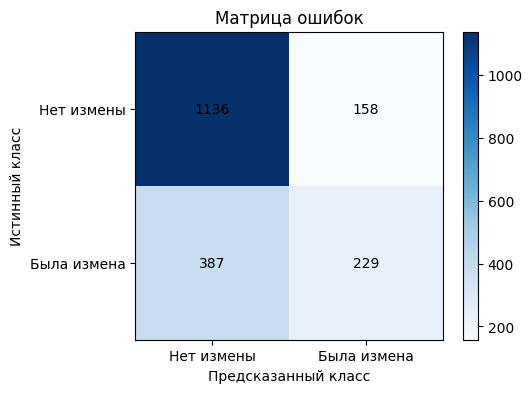

In [8]:
# Матрица ошибок: строки — истина, столбцы — прогноз
cm = confusion_matrix(y_test, y_pred)
print(cm)
plot_confusion_heatmap(cm)


### Короткий вывод

1. Чаще определяются **ложноотрицательные** ошибки (FN ≈ 387): была измена, а модель сказала «нет». Ложноположительных меньше (FP ≈ 158).
2. Accuracy этого не показывает: можно хорошо угадывать частый класс «нет измены» и при этом плохо ловить редкий класс «была измена».


## 4. ROC-кривая и Precision-Recall кривая

Используя вероятности положительного класса:

1. постройте ROC-кривую и посчитайте `ROC-AUC`;
2. постройте Precision-Recall curve и посчитайте `Average Precision (AP)`.

Затем кратко сравните, что показывают эти две метрики.


In [ ]:
# ROC: при разных порогах считаем долю ложных и верных срабатываний
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# PR: как меняются Precision и Recall при разных порогах
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

# Для подписи на графике используем то же значение Average Precision
pr_auc = ap_score

print("ROC-AUC:", roc_auc)
print("Average Precision (Average Precision):", ap_score)


ROC-AUC: 0.7397667054738152
Average Precision (AP): 0.5572323556444373


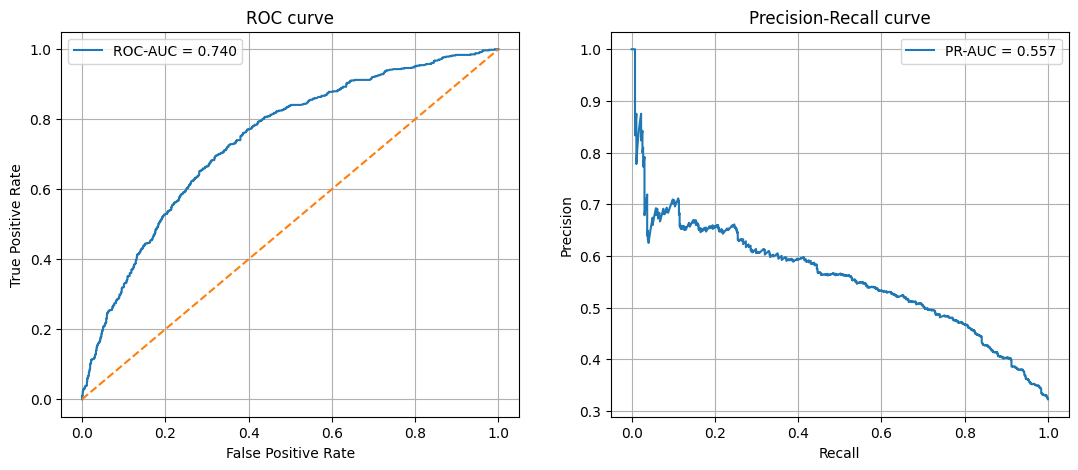

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True)

plt.show()

### Короткий вывод

1. **ROC-AUC ≈ 0.74** — насколько хорошо модель **ранжирует** объекты: больным/«измена» чаще даёт большую вероятность, чем «без измены».
2. **Average Precision ≈ 0.56** — среднее качество по Precision при разных уровнях Recall; смотрит именно на работу с положительным классом.
3. При дисбалансе AP полезнее: ROC может выглядеть лучше за счёт большого числа отрицательных примеров, а Average Precision сильнее наказывает за слабый поиск редкого класса.


## 5. Кросс-валидация

Сравните устойчивость качества модели тремя способами:

1. несколько обычных train/test split с разными `random_state`;
2. `KFold`;
3. `StratifiedKFold`.

Для сравнения используйте метрику **F1**.

In [ ]:
# === Способ 1: несколько обычных train/test split ===
# Идея: 5 раз делим данные по-разному (random_state = 0,1,2,3,4)
# и смотрим, насколько F1 изменяется от разбиения к разбиению.
holdout_scores = []  # сфиксируем F1 с каждого разбиения

for rs in range(5): 
    
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=rs,  # меняем только это — получаем новое разбиение
        stratify=y
    )

    # Каждый раз учим модель заново на своём train
    model_tmp = build_model()
    model_tmp.fit(X_train_tmp, y_train_tmp)

    # Оцениваем только на своём test
    pred_tmp = model_tmp.predict(X_test_tmp)
    score_tmp = f1_score(y_test_tmp, pred_tmp)  # метрика сравнения — F1
    holdout_scores.append(score_tmp)

# Массив из 5 значений F1 для способа 1
holdout_scores = np.array(holdout_scores)
holdout_scores


array([0.45649949, 0.46121593, 0.44536941, 0.44117647, 0.46280992])

In [ ]:
# === Способ 2: KFold ===
# Делим ВСЮ выборку на 5 частей (фолдов).
# По очереди: 4 части — обучение, 1 часть — проверка.
# shuffle=True перемешивает перед делением, при этом баланс классов НЕ гарантируется.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# === Способ 3: StratifiedKFold ===
# Тоже 5 фолдов, но в КАЖДОМ фолде доля классов почти как во всей выборке.
# Для классификации с дисбалансом это результат должен быть лучше, чем обычный KFold.
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score сам крутит фолды, учит модель и считает F1 на каждом фолде
kfold_scores = cross_val_score(build_model(), X, y, cv=kfold, scoring="f1")
skfold_scores = cross_val_score(build_model(), X, y, cv=skfold, scoring="f1")

# Сводка: среднее F1 и разброс (std) по трём способам оценки
cv_summary = pd.DataFrame({
    "method": ["Repeated holdout", "KFold", "StratifiedKFold"],
    "mean_f1": [holdout_scores.mean(), kfold_scores.mean(), skfold_scores.mean()],  # среднее качество
    "std_f1": [holdout_scores.std(), kfold_scores.std(), skfold_scores.std()]  # насколько метрика прыгает
})

display(cv_summary)


,method,mean_f1,std_f1
0,Repeated holdout,0.453414,0.008639
1,KFold,0.450965,0.023413
2,StratifiedKFold,0.449040,0.017023


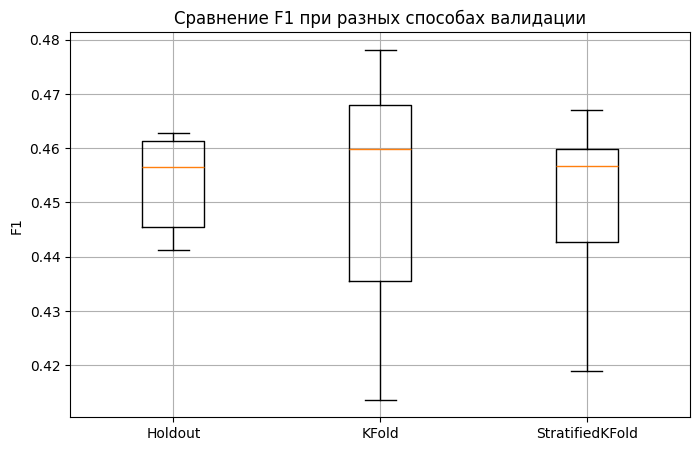

In [13]:
plt.figure(figsize=(8, 5))
plt.boxplot([holdout_scores, kfold_scores, skfold_scores], labels=["Holdout", "KFold", "StratifiedKFold"])
plt.title("Сравнение F1 при разных способах валидации")
plt.ylabel("F1")
plt.grid(True)
plt.show()

### Короткий вывод

1. Среднее F1 у всех способов близкое (~0.45). Разброс меньше у **repeated holdout** (с `stratify`), затем у **StratifiedKFold**; у обычного **KFold** разброс больше.
2. `StratifiedKFold` предпочтительнее в классификации: каждый фолд похож на всю выборку по доле классов из-за этого оценка честнее и стабильнее.


## 6. Сравнение L1- и L2-регуляризации

### Что это простыми словами

Регуляризация — **штраф за слишком большие веса** модели.  
Мы не даём логистической регрессии «запомнить» шум в данных про измены.

В нашей задаче модель предсказывает `affair_flag` по признакам (возраст, годы брака, дети и т.д.).  
Без штрафа веса некоторых признаков могут стать огромными → риск **переобучения**.  
Со штрафом модель проще и обычно лучше обобщает на test.

| | **L1** (`penalty="l1"`) | **L2** (`penalty="l2"`) |
|--|--|--|
| Идея | Штраф за **сумму модулей** весов | Штраф за **сумму квадратов** весов |
| Эффект | Может **обнулять** слабые признаки (отбор) | Уменьшает веса, но обычно **не обнуляет** |
| Аналогия | Выключает лишние рычаги | Приглушает все рычаги понемногу |

**Параметр `C`:** это «обратная сила» регуляризации.
- `C = 0.01` → штраф **сильный** → модель сильно ограничена (риск **недообучения**);
- `C = 1` → штраф **слабее** → модели больше свободы.

### Что сравниваем

Чтобы не перегружать задание, сравните только 4 конфигурации:

- L1, `C = 0.01`
- L1, `C = 1`
- L2, `C = 0.01`
- L2, `C = 1`

Для каждой модели посчитайте:
- `train_accuracy`
- `test_accuracy`
- `train_f1`
- `test_f1`
- `train_roc_auc`
- `test_roc_auc`

Сравните результаты и сделайте вывод, есть ли признаки переобучения или недообучения.


In [14]:
# Четыре настройки: сильная/слабая регуляризация для L1 и L2
configs = [
    ("l1", 0.01),  # L1 и сильный штраф
    ("l1", 1.0),   # L1 и слабый штраф
    ("l2", 0.01),  # L2 и сильный штраф
    ("l2", 1.0),   # L2 и слабый штраф
]
configs


[('l1', 0.01), ('l1', 1.0), ('l2', 0.01), ('l2', 1.0)]

In [15]:
# Сравниваем 4 настройки регуляризации
reg_results = []

for penalty, C in configs:
    # C маленький = регуляризация сильнее; C большой = слабее
    model = build_model(penalty=penalty, C=C)
    model.fit(X_train, y_train)

    # Предсказания классов
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Вероятности класса 1 для ROC-AUC
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    reg_results.append({
        "penalty": penalty,
        "C": C,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_f1": f1_score(y_train, train_pred),
        "test_f1": f1_score(y_test, test_pred),
        "train_roc_auc": roc_auc_score(y_train, train_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
    })

reg_results = pd.DataFrame(reg_results)
display(reg_results)


,penalty,C,train_accuracy,test_accuracy,train_f1,test_f1,train_roc_auc,test_roc_auc
0,l1,0.01,0.723294,0.708901,0.423562,0.417191,0.738363,0.735156
1,l1,1.00,0.728680,0.715183,0.465281,0.457086,0.745423,0.739829
2,l2,0.01,0.727110,0.714660,0.457143,0.452261,0.743686,0.739049
3,l2,1.00,0.728232,0.714660,0.463922,0.456630,0.745392,0.739767


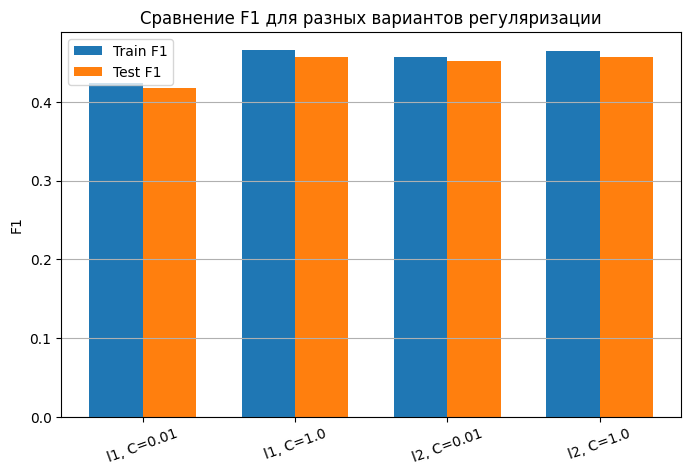

In [16]:
plt.figure(figsize=(8, 5))
labels = reg_results["penalty"] + ", C=" + reg_results["C"].astype(str)
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, reg_results["train_f1"], width=width, label="Train F1")
plt.bar(x + width/2, reg_results["test_f1"], width=width, label="Test F1")

plt.xticks(x, labels, rotation=20)
plt.ylabel("F1")
plt.title("Сравнение F1 для разных вариантов регуляризации")
plt.legend()
plt.grid(True, axis="y")
plt.show()

### Короткий вывод

1. Лучший результат на test у **L1, C=1** (F1 ≈ 0.457, accuracy ≈ 0.715, ROC-AUC ≈ 0.740); **L2, C=1** почти такой же.
2. Недообучение заметнее при **C=0.01** (особенно L1): и train, и test F1 ниже — модель слишком «зажата».
3. Явного переобучения нет: train и test метрики близки во всех четырёх вариантах.
4. В этой задаче удачнее **слабая регуляризация (C=1)**; между L1 и L2 разница совсем небольшая, L1 чуть лучше по test F1.


# Итоговый вывод

1. **Accuracy недостаточно**: при дисбалансе (~32% измен) можно получать ~0.71 accuracy, плохо находя положительный класс (recall ≈ 0.37).
2. **F1** показывает баланс Precision/Recall по классу «измена». **ROC-AUC** оценивает умение ранжировать. **AP** особенно полезен при интересе к редкому положительному классу.
3. **Кросс-валидация** нужна, чтобы не зависеть от одного случайного split: смотрим среднее качество и разброс.
4. **Регуляризация** ограничивает веса модели. Слишком сильная (C=0.01) здесь дала недообучение; умеренная (C=1) работает лучше и не раздувает разрыв train/test.
5. Лучше всего себя показала **логистическая регрессия с L1, C=1** (почти неотличима от L2, C=1): test F1 ≈ 0.46, ROC-AUC ≈ 0.74.
